<a href="https://colab.research.google.com/github/Saarim02/CPU-Scheduling-Algorithms/blob/main/KMeans.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Load dataset
df = pd.read_csv("/content/drive/MyDrive/Datasets/Live.csv")

In [ ]:
# Select relevant numeric features for clustering
features = ['num_reactions', 'num_comments', 'num_shares', 'num_likes',
            'num_loves', 'num_wows', 'num_hahas', 'num_sads', 'num_angrys']
df_clean = df[features].dropna()


In [ ]:
# Normalize the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_clean)


In [ ]:
# Apply PCA for 2D visualization
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)


In [ ]:
# Apply K-Means clustering
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(scaled_data)


In [ ]:
# Add PCA and cluster info to DataFrame
df_clean['PCA1'] = pca_data[:, 0]
df_clean['PCA2'] = pca_data[:, 1]
df_clean['Cluster'] = clusters

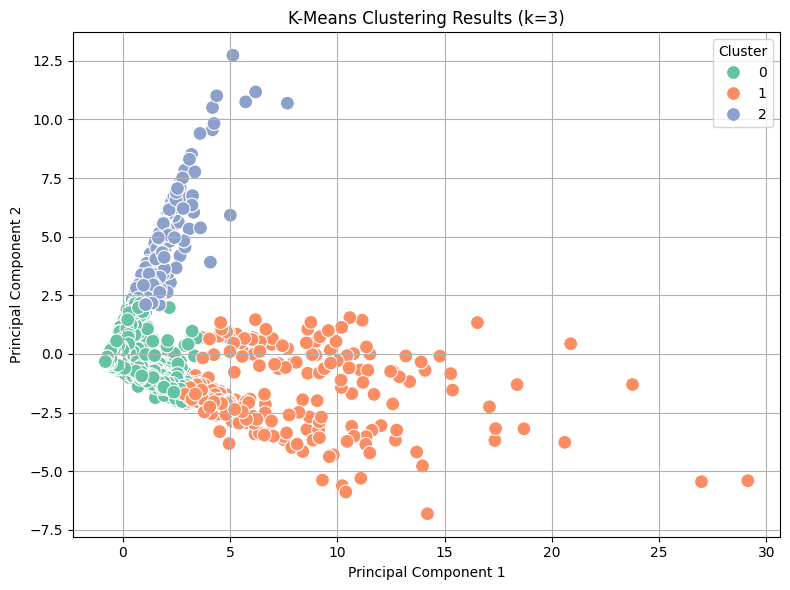

In [ ]:
# Plot clusters
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_clean, x='PCA1', y='PCA2', hue='Cluster', palette='Set2', s=100)
plt.title("K-Means Clustering Results (k=3)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title='Cluster')
plt.grid(True)
plt.tight_layout()
plt.show()